In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from os.path import join, exists
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from PIL import Image
from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data.sampler import SubsetRandomSampler, WeightedRandomSampler
from torch.utils.data import DataLoader, Subset, Dataset
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder, DatasetFolder
!pip install torchinfo
import torchinfo

# set seed
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# get data and unzip (if not already)
if not exists('data_cleaned'):
  !unzip "/content/drive/My Drive/aps360/project_data_final"
else:
  print('Data already loaded')

Streaming output truncated to the last 5000 lines.
  inflating: data_cleaned/images/00011460_045.jpg  
  inflating: data_cleaned/images/augmented_bronchiolitis_1380_no_nih.jpg  
  inflating: data_cleaned/images/augmented_effusion_580.jpg  
  inflating: data_cleaned/images/augmented_other_1643_no_nih.jpg  
  inflating: data_cleaned/images/BACTERIA-8324394-0003.jpg  
  inflating: data_cleaned/images/augmented_bronchiolitis_608.jpg  
  inflating: data_cleaned/images/30dec6ef178a3b5dcf8fd90c3c36dc86.jpg  
  inflating: data_cleaned/images/9b50c0470a24ebfb77cc300ec5e7d5ba.jpg  
  inflating: data_cleaned/images/5c2380574fb43f463747168b521acdc3.jpg  
  inflating: data_cleaned/images/augmented_other_1455_no_nih.jpg  
  inflating: data_cleaned/images/augmented_heart disease_1493_no_nih.jpg  
  inflating: data_cleaned/images/augmented_broncho-pnuemonia_1389_no_nih.jpg  
  inflating: data_cleaned/images/augmented_bronchiolitis_994.jpg  
  inflating: data_cleaned/images/augmented_effusion_951.jpg  

In [3]:
BASE_DATA_PATH = 'data_cleaned'
IMAGE_PATH = join(BASE_DATA_PATH, 'images')
ANNOT_PATH = join(BASE_DATA_PATH, 'annotations')

In [4]:
df = pd.read_csv(join(ANNOT_PATH, 'master_alternate_augmented.csv'))
n = len(df)
value_counts = df['label'].value_counts()
print(f"Total Samples: {n}")
print(value_counts)

Total Samples: 21740
label
no finding           2174
pneumonia            2174
heart disease        2174
other                2174
consolidation        2174
infiltration         2174
effusion             2174
bronchiolitis        2174
bronchitis           2174
broncho-pnuemonia    2174
Name: count, dtype: int64


In [5]:
## NOTE: UPDATE IMAGE SIZES TO BE 130x100 OR ELSE
## DOES NOT FIT INTO LOCAL OR COLAB RAM

from skimage import io
from skimage.transform import resize
from copy import deepcopy

df_new = deepcopy(df)
# DESIRED_IMG_SIZE = (520,400)
DESIRED_IMG_SIZE = (130, 100)

save_folder = 'data_small'
if not exists(save_folder):
  os.makedirs(save_folder)

for i in tqdm(range(len(df))):
  row = df.iloc[i]
  fname = row['filename']
  # load image
  img_path = os.path.join(IMAGE_PATH, fname)
  img = Image.open(img_path).convert('L')
  img = np.array(img)
  scaled_x = DESIRED_IMG_SIZE[0] / img.shape[0]
  scaled_y = DESIRED_IMG_SIZE[1] / img.shape[1]
  if not exists(join(save_folder, fname)):
    # resize
    img_resized = resize(img, DESIRED_IMG_SIZE, anti_aliasing=True)
    img_resized = (img_resized * 255).astype(np.uint8)
    # save
    save_path = join(save_folder, fname)
    Image.fromarray(img_resized).save(save_path)

  # update bbox in df_new if needed
  if row['has bbox']:
    df_new.at[i, 'min_x'] = row['min_x'] * scaled_x
    df_new.at[i, 'min_y'] = row['min_y'] * scaled_y
    df_new.at[i, 'width'] = row['width'] * scaled_x
    df_new.at[i, 'height'] = row['height'] * scaled_y

100%|██████████| 21740/21740 [02:16<00:00, 159.66it/s]


In [6]:
# BASE_DATA_PATH = '/home/orrin/aps360/pediatric-cxr-model/data_cleaned'
# IMAGE_PATH = join(BASE_DATA_PATH, 'images')
IMAGE_PATH = join(save_folder)
df_new.to_csv('master_alternate_augmented_small.csv', index=False)
# ANNOT_PATH = join(BASE_DATA_PATH, 'annotations')
ANNOT_PATH = os.path.curdir

In [7]:
# define custom dataset
class CXRClassificationDataset(Dataset):
    def __init__(self, csv_file, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        self.data = pd.read_csv(csv_file)
        # Encode labels as integers
        self.label_encoder = LabelEncoder()
        self.data['label_encoded'] = self.label_encoder.fit_transform(self.data['label'])
        self.label_decoder = {i: label for i, label in enumerate(self.label_encoder.classes_)}

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name = join(self.image_dir, self.data.iloc[idx]['filename'])
        image = Image.open(img_name).convert('L')  # convert to grayscale
        label = self.data.iloc[idx]['label_encoded']
        if self.transform:
            image = self.transform(image)
        return image, label

In [8]:
def ConvBlock(in_channels, out_channels, kernel_size=3, stride=1, padding=1, dropout=0.2):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
        nn.SiLU(inplace=True),
        nn.BatchNorm2d(out_channels),
        nn.Dropout2d(dropout)
    )

def FeedForwardBlock(in_features, out_features, dropout=0.2):
    return nn.Sequential(
        nn.Linear(in_features, out_features),
        nn.SiLU(inplace=True),
        nn.BatchNorm1d(out_features),
        nn.Dropout(dropout)
    )

def FeedForwardLastLayer(in_features, out_features):
    return nn.Sequential(
        nn.Linear(in_features, out_features),
    )

class ComposableCNN(nn.Module):
    def __init__(self, conv_params):
        super(ComposableCNN, self).__init__()
        self.params = conv_params
        self.n_conv_layers = len(conv_params)

        for i, (in_ch, out_ch, k, s, p, d) in enumerate(conv_params):
            setattr(self, f'block{i+1}', ConvBlock(in_ch, out_ch, k, s, p, d))

    def forward(self, x):
        for i in range(1, self.n_conv_layers + 1):
            block = getattr(self, f'block{i}')
            x = block(x)
        return x

class ComposableFFN(nn.Module):
    def __init__(self, fc_params):
        super(ComposableFFN, self).__init__()
        self.params = fc_params
        self.n_ff_layers = len(fc_params)

        for i, (in_ch, out_ch, d) in enumerate(fc_params):
            if i == self.n_ff_layers - 1:
                setattr(self, f'block{i+1}', FeedForwardLastLayer(in_ch, out_ch))
            else:
                setattr(self, f'block{i+1}', FeedForwardBlock(in_ch, out_ch, d))

    def forward(self, x):
        for i in range(1, self.n_ff_layers + 1):
            block = getattr(self, f'block{i}')
            x = block(x)
        return x

class PediatricCXRClassificationModel(nn.Module):
    def __init__(self, name, conv_params, fc_params):
        super(PediatricCXRClassificationModel, self).__init__()
        self.name = name
        self.cnn = ComposableCNN(conv_params)
        self.ffn = ComposableFFN(fc_params)

    def forward(self, x):
        x = self.cnn(x)
        x = torch.flatten(x, 1)  # Flatten all dimensions except batch
        x = self.ffn(x)
        return x

In [ ]:
# Define convolutional parameters for a five-layer CNN
# (in_channels, out_channels, kernel_size, stride, padding, dropout)
conv_params = [
    (1, 4, 3, 2, 1, 0.2),   # Input: (1, 130, 100) -> Output: (4, 65, 50)
    (4, 8, 3, 2, 1, 0.2),  # Input: (4, 65, 50) -> Output: (8, 33, 25)
    (8, 16, 3, 2, 1, 0.2),  # Input: (8, 33, 25) -> Output: (16, 17, 13)
    (16, 32, 3, 2, 1, 0.2), # Input: (16, 17, 13) -> Output: (32, 9, 7)
    (32, 64, 3, 2, 1, 0.2) # Input: (32, 9, 7) -> Output: (64, 5, 4)
]

# Calculate the input size for the feedforward network based on CNN output
# Last CNN layer output channels: 64
# Last CNN layer output height: 5
# Last CNN layer output width: 4
ffn_input_size = 64 * 5 * 4 # This is 1280 (64 * 5 * 4)

# Define feedforward parameters for a two-layer FFN
# (in_features, out_features, dropout)
fc_params = [
    (ffn_input_size, 16, 0.5), # First hidden layer
    (16, 10, 0.0) # Output layer for 10 classes (dropout not applied to output)
]

# Create the PediatricCXRClassificationModel
model = PediatricCXRClassificationModel('interim', conv_params, fc_params)
torchinfo.summary(model, input_size=(1, 1, 130, 100))

Layer (type:depth-idx)                   Output Shape              Param #
PediatricCXRClassificationModel          [1, 10]                   --
├─ComposableCNN: 1-1                     [1, 64, 5, 4]             --
│    └─Sequential: 2-1                   [1, 4, 65, 50]            --
│    │    └─Conv2d: 3-1                  [1, 4, 65, 50]            40
│    │    └─SiLU: 3-2                    [1, 4, 65, 50]            --
│    │    └─BatchNorm2d: 3-3             [1, 4, 65, 50]            8
│    │    └─Dropout2d: 3-4               [1, 4, 65, 50]            --
│    └─Sequential: 2-2                   [1, 8, 33, 25]            --
│    │    └─Conv2d: 3-5                  [1, 8, 33, 25]            296
│    │    └─SiLU: 3-6                    [1, 8, 33, 25]            --
│    │    └─BatchNorm2d: 3-7             [1, 8, 33, 25]            16
│    │    └─Dropout2d: 3-8               [1, 8, 33, 25]            --
│    └─Sequential: 2-3                   [1, 16, 17, 13]           --
│    │    └─Con

In [ ]:
conv_params = [
    (1, 4, 7, 2, 1, 0.4),   # Input: (1, 130, 100) -> Output: (4, 63, 48)
    (4, 8, 3, 2, 1, 0.4),  # Input: (4, 63, 48) -> Output: (8, 32, 24)
    (8, 16, 5, 2, 1, 0.4),  # Input: (8, 32, 24) -> Output: (16, 15, 11)
    (16, 32, 3, 2, 1, 0.4), # Input: (16, 15, 11) -> Output: (32, 8, 6)
    (32, 64, 3, 2, 1, 0.4)  # Input: (32, 8, 6) -> Output: (64, 4, 3)
]

# Calculate the input size for the feedforward network based on CNN output
# Last CNN layer output channels: 64
# Last CNN layer output height: 4
# Last CNN layer output width: 3
ffn_input_size = 64 * 4 * 3 # This is 768

# Define feedforward parameters for a two-layer FFN
# (in_features, out_features, dropout)
fc_params = [
    (ffn_input_size, 32, 0.4), # First hidden layer
    (32, 16, 0.4),
    (16, 10, 0.0) # Output layer for 10 classes (dropout not applied to output)
]

# Create the PediatricCXRClassificationModel
model = PediatricCXRClassificationModel('final_old', conv_params, fc_params)
torchinfo.summary(model, input_size=(1, 1, 130, 100))

Layer (type:depth-idx)                   Output Shape              Param #
PediatricCXRClassificationModel          [1, 10]                   --
├─ComposableCNN: 1-1                     [1, 64, 4, 3]             --
│    └─Sequential: 2-1                   [1, 4, 63, 48]            --
│    │    └─Conv2d: 3-1                  [1, 4, 63, 48]            200
│    │    └─SiLU: 3-2                    [1, 4, 63, 48]            --
│    │    └─BatchNorm2d: 3-3             [1, 4, 63, 48]            8
│    │    └─Dropout2d: 3-4               [1, 4, 63, 48]            --
│    └─Sequential: 2-2                   [1, 8, 32, 24]            --
│    │    └─Conv2d: 3-5                  [1, 8, 32, 24]            296
│    │    └─SiLU: 3-6                    [1, 8, 32, 24]            --
│    │    └─BatchNorm2d: 3-7             [1, 8, 32, 24]            16
│    │    └─Dropout2d: 3-8               [1, 8, 32, 24]            --
│    └─Sequential: 2-3                   [1, 16, 15, 11]           --
│    │    └─Co

In [9]:
conv_params = [
    (1, 4, 7, 4, 1, 0.4),   # Input: (1, 130, 100) -> Output: (4, 32, 24) (increased stride to 4)
    (4, 8, 5, 2, 1, 0.4),  # Input: (4, 32, 24) -> Output: (8, 15, 11)
    (8, 16, 7, 2, 1, 0.4)  # Input: (8, 15, 11) -> Output: (16, 6, 4)
]

# Calculate the input size for the feedforward network based on CNN output
# Last CNN layer output channels: 16
# Last CNN layer output height: 6
# Last CNN layer output width: 4
ffn_input_size = 16 * 6 * 4 # This is 384

# Define feedforward parameters for a two-layer FFN
# (in_features, out_features, dropout)
fc_params = [
    (ffn_input_size, 16, 0.4), # Reduced out_features from 64 to 16
    (16, 10, 0.0) # Output layer for 10 classes (dropout not applied to output)
]

# Create the PediatricCXRClassificationModel
model = PediatricCXRClassificationModel('final', conv_params, fc_params)
torchinfo.summary(model, input_size=(1, 1, 130, 100))

Layer (type:depth-idx)                   Output Shape              Param #
PediatricCXRClassificationModel          [1, 10]                   --
├─ComposableCNN: 1-1                     [1, 16, 6, 4]             --
│    └─Sequential: 2-1                   [1, 4, 32, 24]            --
│    │    └─Conv2d: 3-1                  [1, 4, 32, 24]            200
│    │    └─SiLU: 3-2                    [1, 4, 32, 24]            --
│    │    └─BatchNorm2d: 3-3             [1, 4, 32, 24]            8
│    │    └─Dropout2d: 3-4               [1, 4, 32, 24]            --
│    └─Sequential: 2-2                   [1, 8, 15, 11]            --
│    │    └─Conv2d: 3-5                  [1, 8, 15, 11]            808
│    │    └─SiLU: 3-6                    [1, 8, 15, 11]            --
│    │    └─BatchNorm2d: 3-7             [1, 8, 15, 11]            16
│    │    └─Dropout2d: 3-8               [1, 8, 15, 11]            --
│    └─Sequential: 2-3                   [1, 16, 6, 4]             --
│    │    └─Co

In [10]:
csv_file = join(ANNOT_PATH, 'master_alternate_augmented_small.csv')
# csv_file = join(ANNOT_PATH, 'master_alternate_augmented.csv')
dataset = CXRClassificationDataset(
    csv_file=csv_file,
    image_dir=IMAGE_PATH,
    transform=transforms.ToTensor()
)

In [11]:
# helper funtion to split train, validation, and test sets and get loaders
# includes utility to get a certain percentage of the data (useful for question 2c)
def get_data_loaders(
    data,
    percent_train,
    percent_validation,
    percent_test,
    batch_size,
    percent_data=1.0,
    use_weighted_sampler=False):
    # Ensure splits add up to one
    assert percent_train + percent_validation + percent_test == 1.0, \
    "Split percentages must add up to 1.0"

    # set seed to always get same loaders
    np.random.seed(seed)
    torch.manual_seed(seed)

    # Get indices for the entire dataset
    full_indices = list(range(len(data)))

    # Randomly select a percentage of the data's indices
    selected_indices = np.random.choice(full_indices, int(len(data) * percent_data), replace=False)

    # Get labels for the selected indices to use for stratification
    selected_labels = [data.data['label_encoded'].iloc[i] for i in selected_indices]

    # Split the selected_indices into training, validation, and testing indices with stratification
    train_indices, validate_test_indices, _, validate_test_labels = train_test_split(
        selected_indices, selected_labels, train_size=percent_train, random_state=seed, stratify=selected_labels)

    validate_indices, test_indices, _, _ = train_test_split(
        validate_test_indices, validate_test_labels, train_size=percent_validation/(percent_validation+percent_test), random_state=seed, stratify=validate_test_labels)

    # Create Subset objects using the original dataset and the split indices
    data_train = Subset(data, train_indices)
    data_validate = Subset(data, validate_indices)
    data_test = Subset(data, test_indices)

    print("Train Size:", len(data_train))
    print("Validation Size:", len(data_validate))
    print("Test Size:", len(data_test))

    # Verify all 10 classes are present in each split
    train_classes = set([data_train.dataset.data['label_encoded'].iloc[i] for i in data_train.indices])
    val_classes = set([data_validate.dataset.data['label_encoded'].iloc[i] for i in data_validate.indices])
    test_classes = set([data_test.dataset.data['label_encoded'].iloc[i] for i in data_test.indices])
    all_classes = set(range(len(data.label_encoder.classes_)))

    if not (all_classes.issubset(train_classes) and all_classes.issubset(val_classes) and all_classes.issubset(test_classes)):
        print("Warning: Not all 10 classes are present in all splits. Consider increasing percent_data or checking data distribution.")
        print(f"Missing in train: {all_classes - train_classes}")
        print(f"Missing in validation: {all_classes - val_classes}")
        print(f"Missing in test: {all_classes - test_classes}")

    # get class distribution in each loader
    if use_weighted_sampler:
        # Get all labels from the training subset. Now data_train is a Subset object.
        train_labels = [data_train.dataset.data['label_encoded'].iloc[i] for i in data_train.indices]
        class_counts = Counter(train_labels)
        # Create a list of weights for each sample
        num_classes = len(data.label_encoder.classes_)
        class_weights = [0.] * num_classes
        for i in range(num_classes):
            class_weights[i] = 1.0 / class_counts[i] if class_counts[i] > 0 else 0.

        sample_weights = [class_weights[label] for label in train_labels]
        sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
        loader_train = DataLoader(data_train, batch_size=batch_size, sampler=sampler)
    else:
        loader_train = DataLoader(data_train, batch_size=batch_size, shuffle=True)

    loader_validate = DataLoader(data_validate, batch_size=batch_size, shuffle=True)
    loader_test = DataLoader(data_test, batch_size=batch_size, shuffle=True)

    return loader_train, loader_validate, loader_test

def get_data_loaders_old(
    data,
    percent_train,
    percent_validation,
    percent_test,
    batch_size,
    percent_data=1.0):
  # Ensure splits add up to one
  assert percent_train + percent_validation + percent_test == 1.0, \
    "Split percentages must add up to 1.0"

  # randomly define data to use based on percent
  indices = np.random.choice(len(data), int(len(data) * percent_data))
  data_to_use = Subset(data, indices)

  # load splits
  data_train, data_validate_test = train_test_split(data_to_use, train_size=percent_train,
                                                    shuffle=True)
  data_validate, data_test = train_test_split(data_validate_test, \
      train_size=percent_validation/(percent_validation+percent_test),
                                              shuffle=True)
  print("Train Size:", len(data_train))
  print("Validation Size:", len(data_validate))
  print("Test Size:", len(data_test))

  # create dataloaders
  loader_train = DataLoader(data_train, batch_size=batch_size, shuffle=True)
  loader_validate = DataLoader(data_validate, batch_size=batch_size, shuffle=True)
  loader_test = DataLoader(data_test, batch_size=batch_size, shuffle=True)

  return loader_train, loader_validate, loader_test

In [12]:
# Functions based off of Lab 2: Cat and Dogs
def get_model_name(name, batch_size, learning_rate, epoch):
    """ Generate a name for the model consisting of all the hyperparameter values

    Args:
        config: Configuration object containing the hyperparameters
    Returns:
        path: A string with the hyperparameter name and value concatenated
    """
    path = "model_{0}_bs{1}_lr{2}_epoch{3}".format(name,
                                                   batch_size,
                                                   learning_rate,
                                                   epoch)
    return path


def evaluate(net, loader, criterion):
    """ Evaluate the network on the validation set.

     Args:
         net: PyTorch neural network object
         loader: PyTorch data loader for the validation set
         criterion: The loss function
     Returns:
         err: A scalar for the avg classification error over the validation set
         loss: A scalar for the average loss function over the validation set
     """
     # set up variables
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    if torch.cuda.is_available():
      net = net.cuda()
    net.eval() # turn off dropout

    # compute correct predictions and loss for each batch
    # save samples for future accuracy prediction
    for i, data in enumerate(loader, 0):
        inputs, labels = data
        if torch.cuda.is_available():
            inputs = inputs.cuda()
            labels = labels.cuda()

        outputs = net(inputs)
        loss = criterion(outputs, labels)

        corr = torch.eq(outputs.argmax(1), labels).sum().item()
        total_correct += corr
        total_loss += loss.item()
        total_samples += outputs.shape[0]

    # compute total accuracy and total loss
    accuracy = float(total_correct) / total_samples
    loss = float(total_loss) / (len(loader))
    return accuracy, loss


def train_net(net,
              train_loader,
              val_loader,
              batch_size=32,
              learning_rate=0.01,
              num_epochs=30,
              checkpoint_freq=20,
              use_weighted_loss=False):

    if torch.cuda.is_available():
      net = net.cuda()
    net.train() # put model into training mode
    ########################################################################
    # Define the Loss function and optimizer
    # The loss function will be Cross Entropy Loss.
    # Optimizer will be SGD with Momentum.

    criterion = None
    if use_weighted_loss:
      # weight cross entropy loss to reduce class imbalance
      all_labels = [
          label for _, label in train_loader.dataset
      ]
      class_counts = Counter(all_labels)
      class_weights = [1.0 / count for count in class_counts.values()]
      class_weights = torch.tensor(class_weights).float()
      if torch.cuda.is_available():
          class_weights = class_weights.cuda()
      criterion = nn.CrossEntropyLoss(weight=class_weights)
    else:
      criterion = nn.CrossEntropyLoss()

    optimizer = optim.SGD(net.parameters(), lr=learning_rate, momentum=0.9)

    ########################################################################
    # Set up some numpy arrays to store the training/test loss/erruracy
    train_acc = np.zeros(num_epochs)
    train_loss = np.zeros(num_epochs)
    val_acc = np.zeros(num_epochs)
    val_loss = np.zeros(num_epochs)

    ########################################################################
    # Train the network
    # Loop over the data iterator and sample a new batch of training data
    # Get the output from the network, and optimize our loss function.
    start_time = time.time()
    for epoch in range(num_epochs):
        total_train_loss = 0.0
        total_train_correct = 0
        total_samples = 0

        for i, data in enumerate(train_loader, 0):
            # Get the inputs
            inputs, labels = data
            if torch.cuda.is_available():
                inputs = inputs.cuda()
                labels = labels.cuda()

            # Zero the parameter gradients
            optimizer.zero_grad()
            # Forward pass, backward pass, and optimize
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # Calculate the statistics
            corr = torch.eq(outputs.argmax(1), labels).sum().item()
            total_train_correct += corr
            total_samples += outputs.shape[0]
            total_train_loss += loss.item()

        train_acc[epoch] = float(total_train_correct) / total_samples
        train_loss[epoch] = float(total_train_loss) / len(train_loader)
        val_acc[epoch], val_loss[epoch] = evaluate(net, val_loader, criterion)
        print(("Epoch {}: Train Accuracy: {}, Train loss: {} |"+
               "Validation Accuracy: {}, Validation loss: {}").format(
                   epoch + 1,
                   train_acc[epoch],
                   train_loss[epoch],
                   val_acc[epoch],
                   val_loss[epoch]))

        # Save the current model (checkpoint) to a file
        model_path = get_model_name(net.name, batch_size, learning_rate, epoch)
        if epoch % checkpoint_freq == 0:
            torch.save(net.state_dict(), model_path)

    print('Finished Training')
    end_time = time.time()
    elapsed_time = end_time - start_time
    print("Total time elapsed: {:.2f} seconds".format(elapsed_time))
    # Write the train/test loss/err into CSV file for plotting later
    np.savetxt("{}_train_acc.csv".format(model_path), train_acc)
    np.savetxt("{}_train_loss.csv".format(model_path), train_loss)
    np.savetxt("{}_val_acc.csv".format(model_path), val_acc)
    np.savetxt("{}_val_loss.csv".format(model_path), val_loss)


def plot_training_curve(path):
    """ Plots the training curve for a model run, given the csv files
    containing the train/validation error/loss.

    Args:
        path: The base path of the csv files produced during training
    """
    import matplotlib.pyplot as plt
    train_acc = np.loadtxt("{}_train_acc.csv".format(path))
    val_acc = np.loadtxt("{}_val_acc.csv".format(path))
    train_loss = np.loadtxt("{}_train_loss.csv".format(path))
    val_loss = np.loadtxt("{}_val_loss.csv".format(path))
    plt.title("Train vs Validation Accuracy")
    n = len(train_acc) # number of epochs
    plt.plot(range(1,n+1), train_acc, label="Train")
    plt.plot(range(1,n+1), val_acc, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(loc='best')
    plt.show()
    plt.title("Train vs Validation Loss")
    plt.plot(range(1,n+1), train_loss, label="Train")
    plt.plot(range(1,n+1), val_loss, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(loc='best')
    plt.show()

def pipeline(
    model,
    dataset,
    batch_size=32,
    learning_rate=0.001,
    num_epochs=10,
    percent_train=0.7,
    percent_validation=0.15,
    percent_test=0.15,
    percent_data=0.05,
    checkpoint_freq=1,
    use_weighted_sampler=False,
    use_weighted_loss=False,
):
    # get data loaders
    loader_train, loader_validate, loader_test = get_data_loaders(
        dataset,
        percent_train=percent_train,
        percent_validation=percent_validation,
        percent_test=percent_test,
        batch_size=batch_size,
        percent_data=percent_data,
        use_weighted_sampler=use_weighted_sampler
    )

    # train model
    train_net(model,
              loader_train,
              loader_validate,
              batch_size=batch_size,
              learning_rate=learning_rate,
              num_epochs=num_epochs,
              checkpoint_freq=checkpoint_freq,
              use_weighted_loss=use_weighted_loss)

def pipeline_old_loader(
    model,
    dataset,
    batch_size=32,
    learning_rate=0.001,
    num_epochs=10,
    percent_train=0.7,
    percent_validation=0.15,
    percent_test=0.15,
    percent_data=0.05,
    checkpoint_freq=1,
    use_weighted_loss=False,
):
    # get data loaders
    loader_train, loader_validate, loader_test = get_data_loaders_old(
        dataset,
        percent_train=percent_train,
        percent_validation=percent_validation,
        percent_test=percent_test,
        batch_size=batch_size,
        percent_data=percent_data,
    )

    # train model
    train_net(model,
              loader_train,
              loader_validate,
              batch_size=batch_size,
              learning_rate=learning_rate,
              num_epochs=num_epochs,
              checkpoint_freq=checkpoint_freq,
              use_weighted_loss=use_weighted_loss)

In [ ]:
# overfit on subset
pipeline(
    model,
    dataset,
    batch_size=32,
    learning_rate=0.01,
    num_epochs=100,
    percent_train=0.7,
    percent_validation=0.15,
    percent_test=0.15,
    percent_data=0.05,
    checkpoint_freq=1,
    use_weighted_sampler=True,
    use_weighted_loss=True
)

Train Size: 760
Validation Size: 163
Test Size: 164
Epoch 1: Train Accuracy: 0.09473684210526316, Train loss: 2.487752993901571 |Validation Accuracy: 0.147239263803681, Validation loss: 2.280293345451355
Epoch 2: Train Accuracy: 0.23157894736842105, Train loss: 2.1159647007783255 |Validation Accuracy: 0.25766871165644173, Validation loss: 1.9575525919596355


KeyboardInterrupt: 

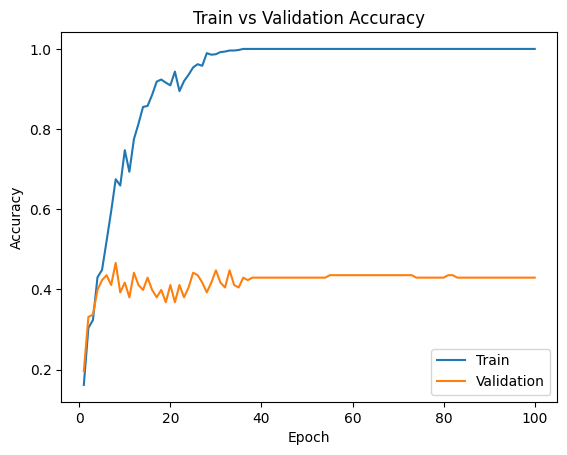

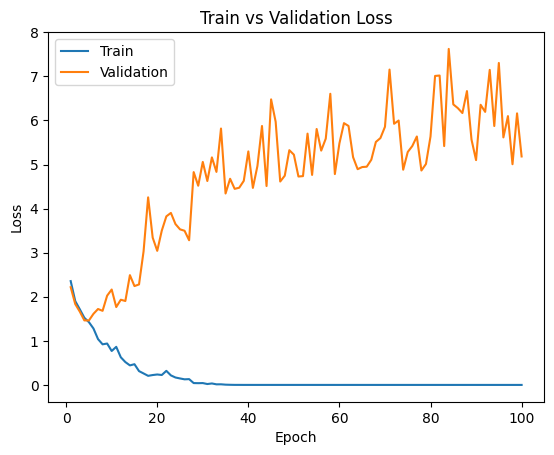

In [ ]:
path = get_model_name(model.name, 32, 0.01, 99)
plot_training_curve(path)

In [ ]:
pipeline(
    model,
    dataset,
    batch_size=264,
    learning_rate=0.001,
    num_epochs=200,
    percent_train=0.7,
    percent_validation=0.15,
    percent_test=0.15,
    percent_data=1.0,
    checkpoint_freq=1,
    use_weighted_sampler=True,
    use_weighted_loss=True,
)

Train Size: 15217
Validation Size: 3261
Test Size: 3262
Epoch 1: Train Accuracy: 0.18538476703686665, Train loss: 2.2350046675780724 |Validation Accuracy: 0.30144127568230605, Validation loss: 1.9189833310934215
Epoch 2: Train Accuracy: 0.49852139055004274, Train loss: 1.322999275963882 |Validation Accuracy: 0.4817540631708065, Validation loss: 1.2539936762589674
Epoch 3: Train Accuracy: 0.5794834724321483, Train loss: 1.0481572336164013 |Validation Accuracy: 0.48574057037718493, Validation loss: 1.2539149614480825
Epoch 4: Train Accuracy: 0.6082013537490965, Train loss: 0.9829230596279276 |Validation Accuracy: 0.4897270775835633, Validation loss: 1.236621150603661
Epoch 5: Train Accuracy: 0.617861602155484, Train loss: 0.9572568936594601 |Validation Accuracy: 0.4897270775835633, Validation loss: 1.2511131855157704
Epoch 6: Train Accuracy: 0.6320562528750739, Train loss: 0.9200112501095081 |Validation Accuracy: 0.48850045998160074, Validation loss: 1.2688563328522902
Epoch 7: Train Acc

In [ ]:
path = get_model_name(model.name, 128, 0.0005, 199)
plot_training_curve(path)

NameError: name 'get_model_name' is not defined

In [13]:
pipeline_old_loader(
    model,
    dataset,
    batch_size=128,
    learning_rate=0.0005,
    num_epochs=300,
    percent_train=0.7,
    percent_validation=0.15,
    percent_test=0.15,
    percent_data=1.0,
    checkpoint_freq=1,
    use_weighted_loss=False,
)

Train Size: 15217
Validation Size: 3261
Test Size: 3262
Epoch 1: Train Accuracy: 0.13241769074061904, Train loss: 2.4262527217384147 |Validation Accuracy: 0.22201778595522845, Validation loss: 2.123037365766672
Epoch 2: Train Accuracy: 0.30873365315108103, Train loss: 1.8774479196852996 |Validation Accuracy: 0.3765716038025146, Validation loss: 1.6413507553247304
Epoch 3: Train Accuracy: 0.3948872971019255, Train loss: 1.5686824351799589 |Validation Accuracy: 0.4271695798834713, Validation loss: 1.4936186762956472
Epoch 4: Train Accuracy: 0.4296510481698101, Train loss: 1.4652056844294572 |Validation Accuracy: 0.45139527752223246, Validation loss: 1.3959614496964674
Epoch 5: Train Accuracy: 0.45232305973582176, Train loss: 1.4006588759542513 |Validation Accuracy: 0.44710211591536336, Validation loss: 1.3908950915703406
Epoch 6: Train Accuracy: 0.46395478740881907, Train loss: 1.3582225106343502 |Validation Accuracy: 0.4688745783501993, Validation loss: 1.3312893005517812
Epoch 7: Train

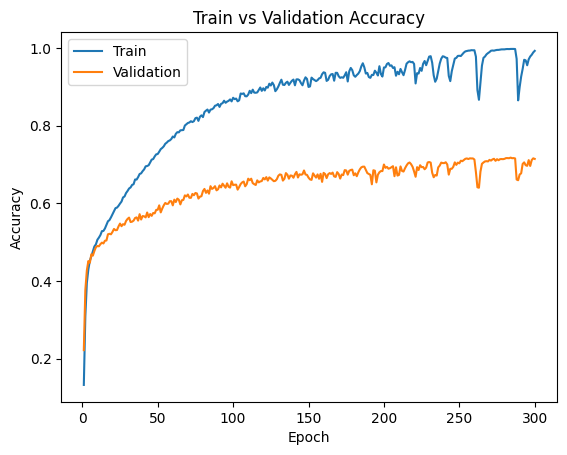

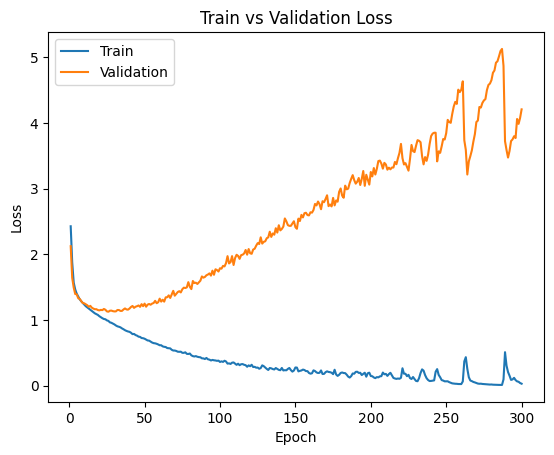

In [14]:
path = get_model_name(model.name, 128, 0.0005, 299)
plot_training_curve(path)

In [15]:
# load best checkpoint
path = get_model_name(model.name, 128, 0.0005, 299)
model.load_state_dict(torch.load(path))


<All keys matched successfully>

In [19]:
# Test model on test set
loader_train, loader_validate, loader_test = get_data_loaders_old(
    dataset,
    percent_train=0.7,
    percent_validation=0.15,
    percent_test=0.15,
    batch_size=128,
    percent_data=1,
)
accuracy, loss = evaluate(model, loader_test, nn.CrossEntropyLoss())
print("Test Accuracy: ", accuracy)
print("Test Loss: ", loss)

Train Size: 15217
Validation Size: 3261
Test Size: 3262
Test Accuracy:  0.7179644389944819
Test Loss:  4.282704784319951


In [38]:
## Error per class and most common wrong class

criterion = nn.CrossEntropyLoss()

# Recreate data loaders with the same parameters as the last training run
# batch_size=128, learning_rate=0.0001, num_epochs=200, percent_train=0.7, percent_validation=0.15, percent_test=0.15, percent_data=1.0, use_weighted_loss=False
loader_train, loader_validate, loader_test = get_data_loaders(
    dataset,
    percent_train=0.7,
    percent_validation=0.15,
    percent_test=0.15,
    batch_size=128,
    percent_data=1.0,
    use_weighted_sampler=False # Ensure consistency with training setup
)

# Initialize per-class correct and total counts
num_classes = len(dataset.label_encoder.classes_)
per_class_correct = list(0. for _ in range(num_classes))
per_class_total = list(0. for _ in range(num_classes))

# Dictionary to store incorrect predictions: {true_label: {wrong_predicted_label: count}}
discrepancies = {i: Counter() for i in range(num_classes)}

# Dictionary to store example misclassified image filenames: { (true_label, predicted_label): [filename1, filename2, ...] }
misclassified_examples = {}

model.eval() # Set the model to evaluation mode

with torch.no_grad(): # Disable gradient calculation during evaluation
    for inputs, labels in loader_validate:
        if torch.cuda.is_available():
            inputs = inputs.cuda()
            labels = labels.cuda()

        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        c = (predicted == labels).squeeze()

        for i in range(len(labels)):
            true_label = labels[i].item() # Convert tensor to scalar
            predicted_label = predicted[i].item()

            # Get filename for the current image
            # We need to access the original dataset through the Subset and its indices
            original_dataset_idx = loader_validate.dataset.indices[i]
            image_filename = dataset.data.iloc[original_dataset_idx]['filename']

            # Update overall correct/total counts
            per_class_total[true_label] += 1
            if c[i].item(): # If correct
                per_class_correct[true_label] += 1
            else: # If incorrect
                discrepancies[true_label][predicted_label] += 1
                # Store filename for misclassified examples (up to 4 per pair)
                pair_key = (true_label, predicted_label)
                if pair_key not in misclassified_examples:
                    misclassified_examples[pair_key] = []
                # if len(misclassified_examples[pair_key]) < 4: # Limit to 4 examples per type of misclassification
                misclassified_examples[pair_key].append(image_filename)

print("Per-class correct predictions on validation set:")
for i, (correct, total) in enumerate(zip(per_class_correct, per_class_total)):
    class_name = dataset.label_decoder[i]
    if total > 0:
        print(f"Class '{class_name}': {int(correct)}/{int(total)} correct ({correct/total:.2%})")
    else:
        print(f"Class '{class_name}': No samples in validation set.")

print("\nMost common wrong class predictions:")
for true_label, wrong_predictions in discrepancies.items():
    true_class_name = dataset.label_decoder[true_label]
    if wrong_predictions:
        most_common_wrong = wrong_predictions.most_common(1)[0]
        wrong_class_name = dataset.label_decoder[most_common_wrong[0]]
        count = most_common_wrong[1]
        print(f"  For true class '{true_class_name}', most common wrong prediction was '{wrong_class_name}' ({count} times).")
    else:
        print(f"  For true class '{true_class_name}', no incorrect predictions were made.")

Train Size: 15217
Validation Size: 3261
Test Size: 3262
Per-class correct predictions on validation set:
Class 'bronchiolitis': 227/326 correct (69.63%)
Class 'bronchitis': 225/326 correct (69.02%)
Class 'broncho-pnuemonia': 217/326 correct (66.56%)
Class 'consolidation': 216/326 correct (66.26%)
Class 'effusion': 221/327 correct (67.58%)
Class 'heart disease': 249/326 correct (76.38%)
Class 'infiltration': 200/326 correct (61.35%)
Class 'no finding': 285/326 correct (87.42%)
Class 'other': 207/326 correct (63.50%)
Class 'pneumonia': 303/326 correct (92.94%)

Most common wrong class predictions:
  For true class 'bronchiolitis', most common wrong prediction was 'broncho-pnuemonia' (38 times).
  For true class 'bronchitis', most common wrong prediction was 'bronchiolitis' (40 times).
  For true class 'broncho-pnuemonia', most common wrong prediction was 'bronchiolitis' (49 times).
  For true class 'consolidation', most common wrong prediction was 'effusion' (40 times).
  For true class 

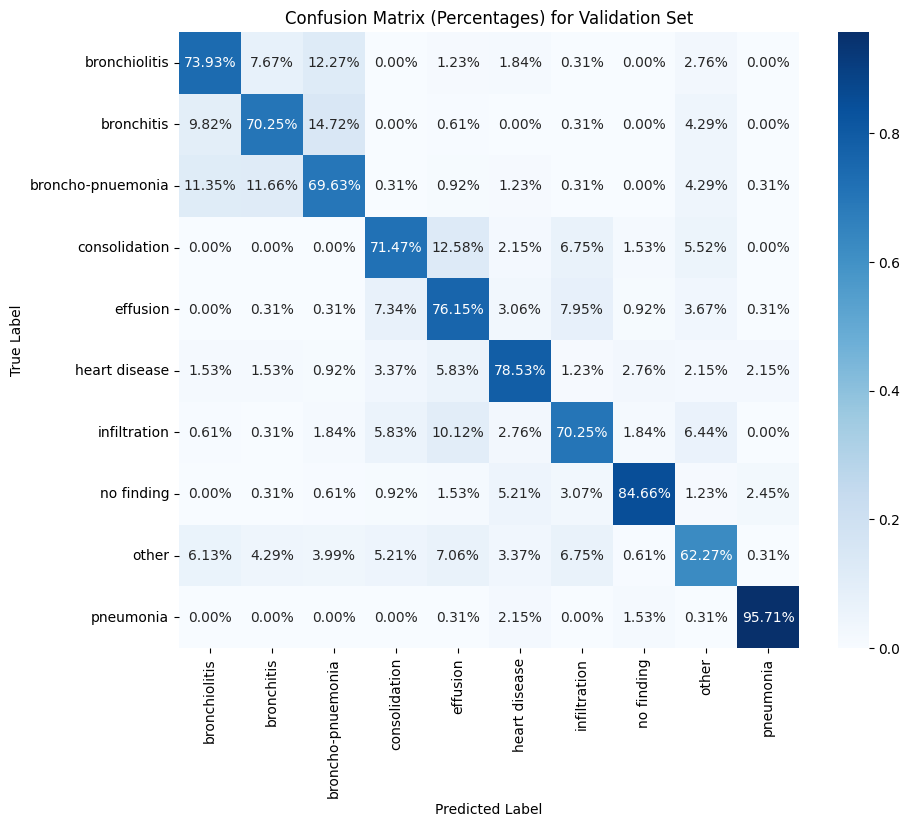

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

criterion = nn.CrossEntropyLoss()

# Recreate data loaders with the same parameters as the last training run
# loader_train, loader_validate, loader_test = get_data_loaders(
#     dataset,
#     percent_train=0.7,
#     percent_validation=0.15,
#     percent_test=0.15,
#     batch_size=128,
#     percent_data=1.0,
#     use_weighted_sampler=False # Ensure consistency with training setup
# )

all_labels = []
all_predicted = []

model.eval() # Set the model to evaluation mode

with torch.no_grad(): # Disable gradient calculation during evaluation
    for inputs, labels in loader_validate:
        if torch.cuda.is_available():
            inputs = inputs.cuda()
            labels = labels.cuda()

        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predicted.extend(predicted.cpu().numpy())

# Calculate the confusion matrix
cm = confusion_matrix(all_labels, all_predicted)

# Normalize the confusion matrix by row (true label) to get percentages
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Get class names for labeling
class_names = [dataset.label_decoder[i] for i in range(len(dataset.label_encoder.classes_))]

# Plot the normalized confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Percentages) for Validation Set')
plt.show()

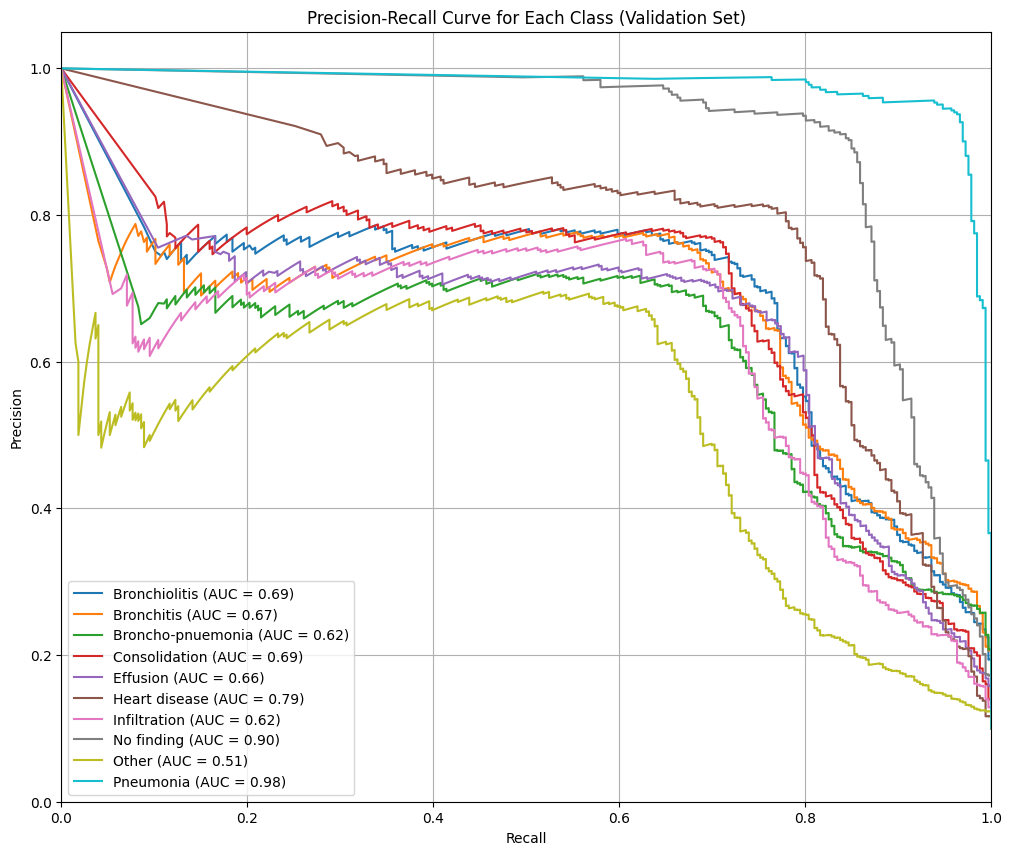

In [ ]:
## Precision recall curve

from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

criterion = nn.CrossEntropyLoss()

# Recreate data loaders with the same parameters as the last training run
# loader_train, loader_validate, loader_test = get_data_loaders(
#     dataset,
#     percent_train=0.7,
#     percent_validation=0.15,
#     percent_test=0.15,
#     batch_size=128,
#     percent_data=1.0,
#     use_weighted_sampler=False # Ensure consistency with training setup
# )

all_labels = []
all_probs = []

model.eval() # Set the model to evaluation mode

with torch.no_grad(): # Disable gradient calculation during evaluation
    for inputs, labels in loader_validate:
        if torch.cuda.is_available():
            inputs = inputs.cuda()
            labels = labels.cuda()

        outputs = model(inputs)
        # Apply softmax to get probabilities for each class
        probs = F.softmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Convert lists to numpy arrays
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

num_classes = len(dataset.label_encoder.classes_)
class_names = [dataset.label_decoder[i] for i in range(num_classes)]

# Binarize the labels for one-vs-rest approach
# Ensure all_labels has at least 2 classes for label_binarize
if num_classes > 1:
    y_true_binarized = label_binarize(all_labels, classes=range(num_classes))
else:
    # Handle case where there's only one class (though unlikely in this context)
    y_true_binarized = (all_labels == 0).astype(int).reshape(-1, 1)

# Setup plot
plt.figure(figsize=(12, 10))

# Compute Precision-Recall curve for each class
for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(y_true_binarized[:, i], all_probs[:, i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'{class_names[i].capitalize()} (AUC = {pr_auc:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Each Class (Validation Set)')
plt.legend(loc='lower left')
plt.grid(True)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.show()

In [ ]:
## precision, recall, tpr, fpr, f1, table

from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import pandas as pd

# Recreate data loaders with the same parameters as the last training run
# loader_train, loader_validate, loader_test = get_data_loaders(
#     dataset,
#     percent_train=0.7,
#     percent_validation=0.15,
#     percent_test=0.15,
#     batch_size=128,
#     percent_data=1.0,
#     use_weighted_sampler=False # Ensure consistency with training setup
# )

# Repopulate all_labels and all_predicted to ensure consistency with the new loader_validate
all_labels = []
all_predicted = []

model.eval() # Set the model to evaluation mode

with torch.no_grad(): # Disable gradient calculation during evaluation
    for inputs, labels in loader_validate:
        if torch.cuda.is_available():
            inputs = inputs.cuda()
            labels = labels.cuda()

        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predicted.extend(predicted.cpu().numpy())

# Convert lists to numpy arrays
all_labels = np.array(all_labels)
all_predicted = np.array(all_predicted)


# Calculate precision, recall, fbeta_score, and support for each class
# using average=None to get per-class scores
precision, recall, f1_score, support = precision_recall_fscore_support(
    all_labels, all_predicted, average=None, labels=range(num_classes)
)

# Calculate confusion matrix for TPR and FPR
cm = confusion_matrix(all_labels, all_predicted, labels=range(num_classes))

# Calculate TPR (Recall) and FPR for each class
tpr = []  # True Positive Rate
fpr = []  # False Positive Rate

for i in range(num_classes):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - (TP + FN + FP)

    tpr_val = TP / (TP + FN) if (TP + FN) > 0 else 0
    fpr_val = FP / (FP + TN) if (FP + TN) > 0 else 0

    tpr.append(tpr_val)
    fpr.append(fpr_val)

# Create a DataFrame to display the metrics
metrics_df = pd.DataFrame({
    'Class': class_names,
    'Precision': precision,
    'Recall (TPR)': recall,
    'FPR': fpr,
    'F1-Score': f1_score,
    'Support': support
})

print("Classification Metrics per Class (Validation Set):")
display(metrics_df)

Classification Metrics per Class (Validation Set):


,Class,Precision,Recall (TPR),FPR,F1-Score,Support
0,bronchiolitis,0.715134,0.739264,0.032709,0.726998,326
1,bronchitis,0.729299,0.702454,0.028961,0.715625,326
2,broncho-pnuemonia,0.667647,0.696319,0.038501,0.681682,326
3,consolidation,0.756494,0.714724,0.025554,0.735016,326
4,effusion,0.655263,0.761468,0.044649,0.704385,327
5,heart disease,0.782875,0.785276,0.024191,0.784074,326
6,infiltration,0.724684,0.702454,0.029642,0.713396,326
7,no finding,0.901961,0.846626,0.010221,0.873418,326
8,other,0.669967,0.622699,0.034072,0.645469,326
9,pneumonia,0.945455,0.957055,0.006133,0.951220,326


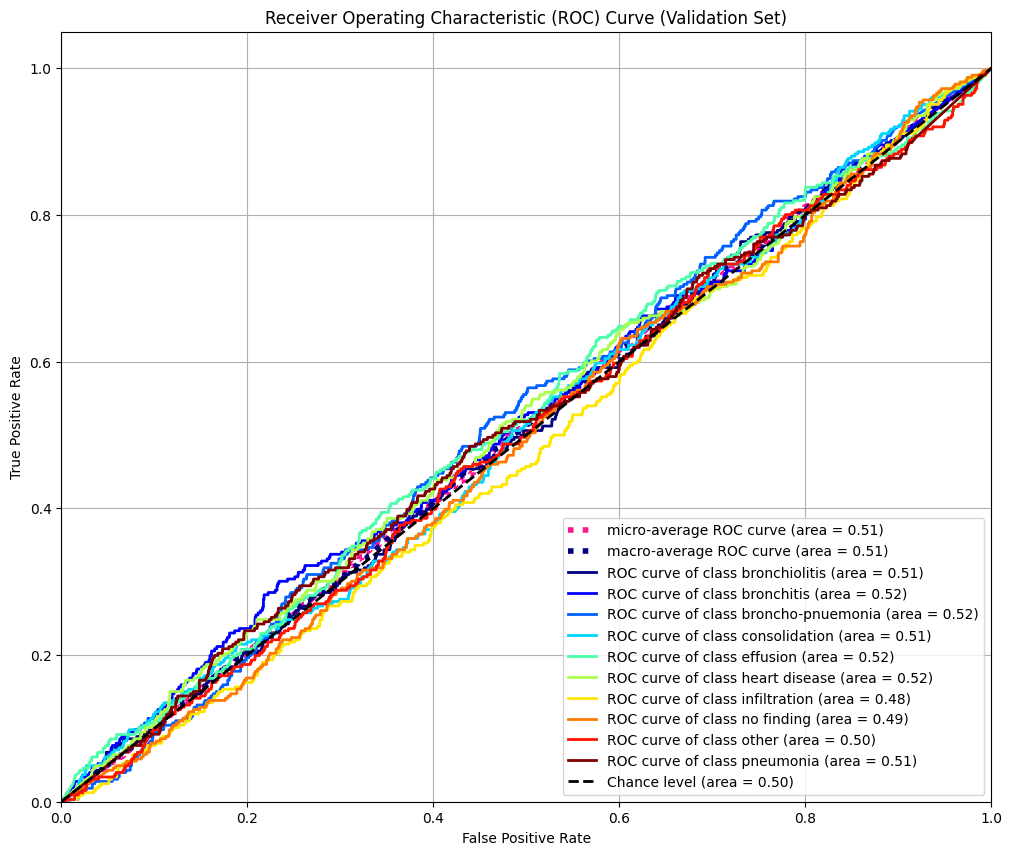

In [ ]:
## ROC

from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Ensure all_labels and all_probs are available from previous cells
# If this is run independently, you might need to re-run the previous cells
# that populate `all_labels` and `all_probs` from loader_validate.

# Convert lists to numpy arrays if not already (from previous cells)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

num_classes = len(dataset.label_encoder.classes_)
class_names = [dataset.label_decoder[i] for i in range(num_classes)]

# Binarize the labels for one-vs-rest approach
y_true_binarized = label_binarize(all_labels, classes=range(num_classes))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_binarized.ravel(), all_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Compute macro-average ROC curve and ROC area
# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))

# Then interpolate all ROC curves at this points
mean_tpr = np.zeros_like(all_fpr)
for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# Average it and compute AUC
mean_tpr /= num_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot all ROC curves
plt.figure(figsize=(12, 10))
plt.plot(fpr["micro"], tpr["micro"],
         label=f'micro-average ROC curve (area = {roc_auc["micro"]:.2f})',
         color='deeppink', linestyle=':', linewidth=4)

plt.plot(fpr["macro"], tpr["macro"],
         label=f'macro-average ROC curve (area = {roc_auc["macro"]:.2f})',
         color='navy', linestyle=':', linewidth=4)

colors = plt.cm.jet(np.linspace(0, 1, num_classes))
for i, color in zip(range(num_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {class_names[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Chance level (area = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Validation Set)')
plt.legend(loc='lower right', prop={'size': 10})
plt.grid(True)
plt.show()

In [ ]:
## SKLEARN classification report

from sklearn.metrics import classification_report
import pandas as pd

# Ensure all_labels and all_predicted are available from previous cells
# If this is run independently, you might need to re-run the previous cells
# that populate `all_labels` and `all_predicted` from loader_validate.

# Convert lists to numpy arrays if not already
all_labels = np.array(all_labels)
all_predicted = np.array(all_predicted)

num_classes = len(dataset.label_encoder.classes_)
class_names = [dataset.label_decoder[i] for i in range(num_classes)]

# Generate the classification report
report = classification_report(
    all_labels, all_predicted,
    labels=range(num_classes),
    target_names=class_names,
    output_dict=False # Set to True to get dictionary output for programmatic use
)

print("Classification Report (Validation Set):")
print(report)

Classification Report (Validation Set):
                   precision    recall  f1-score   support

    bronchiolitis       0.72      0.74      0.73       326
       bronchitis       0.73      0.70      0.72       326
broncho-pnuemonia       0.67      0.70      0.68       326
    consolidation       0.76      0.71      0.74       326
         effusion       0.66      0.76      0.70       327
    heart disease       0.78      0.79      0.78       326
     infiltration       0.72      0.70      0.71       326
       no finding       0.90      0.85      0.87       326
            other       0.67      0.62      0.65       326
        pneumonia       0.95      0.96      0.95       326

         accuracy                           0.75      3261
        macro avg       0.75      0.75      0.75      3261
     weighted avg       0.75      0.75      0.75      3261



### Displaying Misclassified Images

Displaying examples of misclassified images:


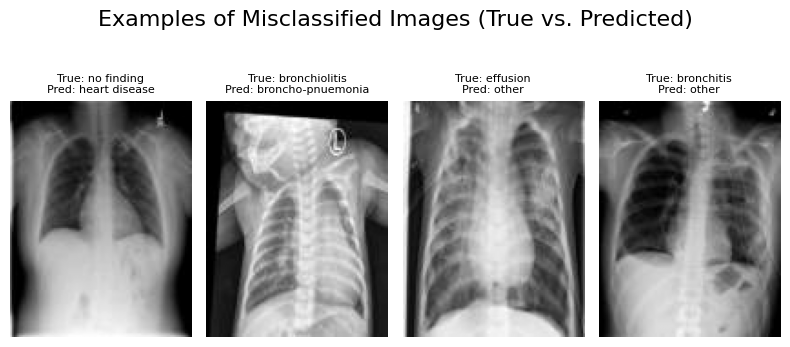

In [116]:
import matplotlib.pyplot as plt
from PIL import Image
import math

# Assuming IMAGE_PATH is defined and points to where the small images are saved
# Assuming dataset.label_decoder is available

print("Displaying examples of misclassified images:")

# Determine how many plots are needed
num_misclassifications = len(misclassified_examples)
if num_misclassifications == 0:
    print("No misclassified examples to display.")
else:
    cols = 4  # Number of columns for the single row
    num_rows = 1 # Only one row

    fig = plt.figure(figsize=(cols * 2, num_rows * 4)) # Adjust figure size appropriately
    fig.suptitle('Examples of Misclassified Images (True vs. Predicted)', fontsize=16)

    # Use a counter for the current subplot position in the single row
    subplot_idx = 0
    for (true_label, predicted_label), filenames in misclassified_examples.items():
        if subplot_idx >= cols: # Stop after filling the 4 columns
            break

        tmp = np.random.rand()
        if tmp > 0.1:
          continue

        true_class_name = dataset.label_decoder[true_label]
        if true_class_name == 'other': # Skip 'other' class
            continue

        predicted_class_name = dataset.label_decoder[predicted_label]

        if filenames: # Ensure there is at least one image for this misclassification type
            fname = filenames[0] # Take the first image for this type
            img_path = os.path.join(IMAGE_PATH, fname)

            if os.path.exists(img_path):
                img = Image.open(img_path).convert('L')

                ax = fig.add_subplot(num_rows, cols, subplot_idx + 1)
                ax.imshow(img, cmap='gray')
                ax.set_title(f'True: {true_class_name}\nPred: {predicted_class_name}', fontsize=8)
                ax.axis('off')
                subplot_idx += 1 # Increment only when an image is successfully plotted
            else:
                print(f"Warning: Image not found at {img_path}")

    plt.tight_layout()
    plt.show()